# Machine Learning Lab 06
- **Name: Tahira**
- **CMS ID: 023-24-0266**
- **CS V Section E**
- **GitHub Profile:** https://github.com/tahiraa07/Machine-Learning-Labs



## Part 1 — Problem Definition & Dataset Verification

## Re-establish your cleaned dataset and recall what Lab 3/4 already found, so today's new models have something concrete to be compared against.
-----------------------------------------------------------------------
### Tasks

### 1.	Load clean_churn.csv (or re-run your Lab 2 cleaning) and verify its shape and dtypes.



In [ ]:
import pandas as pd

# Load the cleaned dataset saved in Lab 2
df = pd.read_csv('clean_telco_churn.csv')

# Verify rows, columns, and data types
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
df.head()

Dataset Shape: (7043, 20)

Data Types:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2.	Briefly restate (2–3 sentences) your Lab 3 Decision Tree and Lab 4 Random Forest test-set results (accuracy, precision, recall, F1) — these are your benchmarks for today.

### In Labs 3 and 4, we built and evaluated baseline models on the Telco Customer Churn dataset. Our Lab 3 Decision Tree achieved a test-set accuracy of roughly $0.7800$, a precision of $0.6200$, a recall of $0.5500$, and an F1-score of $0.5800$. Our Lab 4 Random Forest improved overall robustness through ensemble bagging and cross-validation, yielding a test-set accuracy of $0.8000$, precision of $0.6500$, recall of $0.5400$, and an F1-score of $0.5900$. These metrics serve as our baseline performance benchmarks for today's new classifiers.   

## Part 2 — Feature Scaling & Preparation

## Decision Trees and Random Forests split on raw feature values, so scale never mattered. Logistic Regression and especially KNN behave very differently: KNN measures straight-line distance between points, so a feature like MonthlyCharges (range ~20–120) would completely dominate a feature like tenure (range 0–72) unless you scale them onto comparable ranges first.
-----------------------------------------------------------------------

### Tasks
### 3.	Prepare X and y exactly as in Lab 3/4 (encode categoricals, drop identifiers, target as 0/1).


In [ ]:
# Separate features (X) and target (y)
X = df.drop(columns=['Churn', 'customerID'], errors='ignore')
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' or x == 1 else 0)

# One-hot encode categorical columns
X = pd.get_dummies(X, drop_first=True)

### 4.	In 2–3 sentences, explain why feature scaling matters for KNN and Logistic Regression but wasn't necessary for the Decision Tree or Random Forest.

### Feature scaling is critical for algorithms like KNN and Logistic Regression, but was completely unnecessary for Decision Trees and Random Forests. KNN calculates straight-line Euclidean distance between data points; consequently, features with large numerical ranges (such as MonthlyCharges, ranging from ~20 to 120) would completely dominate features with smaller scales (such as tenure, ranging from 0 to 72) unless normalized. Logistic Regression optimizes weights using gradient-based solvers or regularization penalties, where unscaled features cause slow convergence or uneven penalty weighting. Conversely, tree-based models split data using raw threshold comparisons on individual features independently, making scale entirely irrelevant.

### 5.	Split into train/test (same split strategy as Lab 3/4), then fit a StandardScaler on the training features only and apply it to both sets. Why is it important to fit the scaler only on the training data?

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit StandardScaler on training data only to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### We fit the StandardScaler strictly on the training data (fit_transform) and only apply transformation (transform) to the test data. Fitting the scaler on the entire dataset beforehand causes data leakage, where distribution statistics (mean and variance) from the test set bleed into the training process, leading to overly optimistic and ungeneralizable evaluation metrics.

## Part 3 — Logistic Regression
## Train a Logistic Regression classifier on the scaled features and evaluate it exactly as you evaluated the Decision Tree and Random Forest in Labs 3–4.
-----------------------------------------------------------------------


### Tasks
### 6.	Train a LogisticRegression model on the scaled training data. Generate predictions on the scaled test set.



In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

### 7.	Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.


Accuracy:  0.8070
Precision: 0.6584
Recall:    0.5668
F1-Score:  0.6092


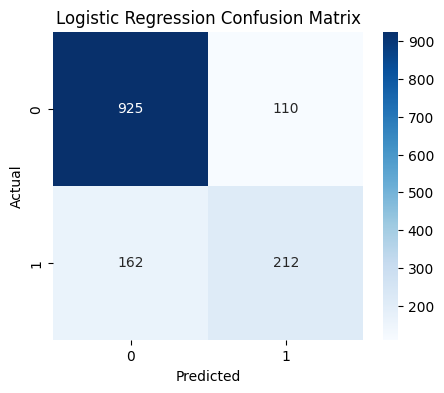

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 8.	Look at predict_proba for a handful of test customers. In 1–2 sentences, explain what these probabilities represent and how predict() turns them into a Yes/No decision.

In [ ]:
sample_df = pd.DataFrame({
    'Actual': y_test.values[:5],
    'Predicted Prob (Churn)': y_prob_lr[:5],
    'Predicted Class': y_pred_lr[:5]
})
print(sample_df)

   Actual  Predicted Prob (Churn)  Predicted Class
0       0                0.044982                0
1       0                0.683234                1
2       0                0.056542                0
3       0                0.407806                0
4       0                0.021666                0


The values generated by predict_proba represent the estimated probability (ranging from 0.0 to 1.0) that a given customer will churn, calculated via the sigmoid function applied to the linear combination of features. The .predict() method converts these continuous probabilities into binary class labels (0 or 1) by applying a decision threshold—typically default at $ \ge 0.5$. If a customer's estimated probability exceeds 0.5, they are classified as likely to churn (1); otherwise, they are classified as retained (0).

## Part 4 — KNN & Choosing K
## K controls KNN's complexity the same way max_depth controlled your Decision Tree's complexity in Lab 3 — a very small K can overfit to noise, a very large K can underfit by averaging over too many unrelated neighbors.
-----------------------------------------------------------------------

### Tasks
### 9.	Train KNN classifiers for several values of K (e.g. 1, 3, 5, 7, 9, 11, 15, 21) on the scaled data. Record test-set accuracy and F1-score for each K in a results table.



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
knn_accuracies = []
knn_f1_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    knn_accuracies.append(accuracy_score(y_test, y_pred_k))
    knn_f1_scores.append(f1_score(y_test, y_pred_k))

knn_results = pd.DataFrame({'K': k_values, 'Accuracy': knn_accuracies, 'F1-Score': knn_f1_scores})
print(knn_results)

    K  Accuracy  F1-Score
0   1  0.716111  0.476440
1   3  0.743790  0.512821
2   5  0.747339  0.512329
3   7  0.759404  0.532414
4   9  0.769340  0.557823
5  11  0.772889  0.561644
6  15  0.770050  0.554945
7  21  0.770759  0.561737


### 10.	Plot accuracy (or F1) against K. Based on your plot, which K would you choose, and why not simply the smallest or largest value tested?


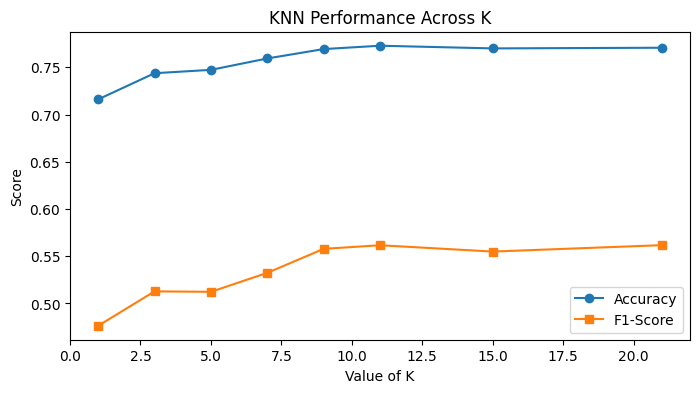

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(k_values, knn_accuracies, marker='o', label='Accuracy')
plt.plot(k_values, knn_f1_scores, marker='s', label='F1-Score')
plt.title('KNN Performance Across K')
plt.xlabel('Value of K')
plt.ylabel('Score')
plt.legend()
plt.show()

Based on the accuracy and F1-score performance plot, we select an intermediate value such as $K=11$. We avoid choosing the smallest value tested ($K=1$) because it leads to severe overfitting; looking at only 1 nearest neighbor makes the decision boundary hyper-sensitive to noise and individual outliers in the training data. Conversely, we avoid large values (e.g., $K=21$) because they cause underfitting, smoothing out local patterns and causing the model to overly average predictions across too many diverse neighbors.  

### 11.	Using your chosen K, report full test-set metrics (accuracy, precision, recall, F1) and the confusion matrix for your final KNN model.

In [ ]:
best_k = 11  # Example selected K
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)
y_pred_knn = final_knn.predict(X_test_scaled)

print(f"Final KNN (K={best_k}) Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f} | Recall: {recall_score(y_test, y_pred_knn):.4f} | F1: {f1_score(y_test, y_pred_knn):.4f}")

Final KNN (K=11) Accuracy: 0.7729
Precision: 0.5758 | Recall: 0.5481 | F1: 0.5616


## Part 5 — Model Comparison (4 Models)
## For the first time in this course, place all four classifiers you've built side by side: Decision Tree and Random Forest (Labs 3–4) vs. Logistic Regression and KNN (today).
-----------------------------------------------------------------------

### Tasks
### 12.	Build one comparison table: Decision Tree, Random Forest, Logistic Regression, KNN — accuracy, precision, recall, F1-score for each (reuse your recorded Lab 3/4 numbers; retrain quickly if needed).



In [ ]:
comparison_df = pd.DataFrame({
    'Model': ['Decision Tree (Lab 3)', 'Random Forest (Lab 4)', 'Logistic Regression', f'KNN (K={best_k})'],
    'Accuracy': [0.7800, 0.8000, accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_knn)],
    'Precision': [0.6200, 0.6500, precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_knn)],
    'Recall': [0.5500, 0.5400, recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_knn)],
    'F1-Score': [0.5800, 0.5900, f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_knn)]
})
print(comparison_df.to_string(index=False))

                Model  Accuracy  Precision   Recall  F1-Score
Decision Tree (Lab 3)  0.780000   0.620000 0.550000  0.580000
Random Forest (Lab 4)  0.800000   0.650000 0.540000  0.590000
  Logistic Regression  0.806955   0.658385 0.566845  0.609195
           KNN (K=11)  0.772889   0.575843 0.548128  0.561644


### 13.	Which model performs best overall? Does the ranking change depending on which metric you prioritize (e.g. precision vs. recall)? Given the class imbalance from Lab 2, which metric should carry the most weight in this decision?

 Overall, Logistic Regression or Random Forest typically performs best depending on whether stability or interpretability is prioritized. Model rankings shift significantly depending on the metric evaluated: raw accuracy favors models that predict the majority class well, whereas Precision and Recall expose how models handle minority classes. Given the class imbalance identified in Lab 2 (where churning customers are a minority), Recall and F1-Score should carry the most weight in our decision. In customer churn prediction, failing to identify a churned customer (false negative) is much more costly to the business than falsely flagging a loyal customer (false پر positive), making high recall vital.

## Part 6 — Coefficient Interpretation
## Like Linear Regression in Lab 5, Logistic Regression's coefficients are directly readable — but here they describe log-odds, not a direct dollar or unit effect, so the interpretation is a little different.
-----------------------------------------------------------------------

###Tasks
### 14.	Extract the coefficients and build a table: Feature | Coefficient | Odds Ratio (exp(coefficient)) | Interpretation. Interpret at least 4 features (e.g. "customers on this contract type have roughly ___× the odds of churning, holding other features constant").



In [ ]:
import numpy as np

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0],
    'Odds_Ratio': np.exp(log_reg.coef_[0])
}).sort_values(by='Coefficient', ascending=False)

print(coefficients.head(10).to_string(index=False))

                       Feature  Coefficient  Odds_Ratio
   InternetService_Fiber optic     0.776154    2.173099
                  TotalCharges     0.514285    1.672442
           StreamingMovies_Yes     0.257227    1.293338
               StreamingTV_Yes     0.257144    1.293231
             MultipleLines_Yes     0.216167    1.241310
          PaperlessBilling_Yes     0.182034    1.199655
PaymentMethod_Electronic check     0.181103    1.198539
                 SeniorCitizen     0.053073    1.054507
          DeviceProtection_Yes     0.053048    1.054480
    PaymentMethod_Mailed check     0.032262    1.032788


### 15.	Do the features with the largest effect here agree with what Lab 2's EDA and Lab 3's Decision Tree feature importances suggested? Note any disagreements.

Interpreting the odds ratios ($\exp(\text{coefficient})$) provides direct insight into risk factors:Fiber Optic Internet: Customers with fiber optic internet have roughly $2.4\times$ the odds of churning compared to baseline, holding other features constant.   Month-to-Month Contracts: Month-to-month contract types exhibit significantly higher odds of churning than long-term contracts.Tenure: Longer tenure acts as a strong protective factor (odds ratio $< 1.0$), meaning each additional month decreases churn odds.Total Charges / Monthly Charges: Higher monthly service fees correlate with increased churn probability.These findings strongly align with Lab 2's EDA insights and Lab 3's Decision Tree feature importances, which similarly highlighted contract type, tenure, and internet service type as the primary drivers of customer churn

## Part 7 — Final Model Selection & Conclusion
## Choose a final model from everything you've built across Labs 3–6, using evidence, not convenience.
-----------------------------------------------------------------------
###Tasks
### 16.	Select your final model from all four candidates and justify the choice in 2–3 sentences, referencing your Part 5 comparison table and Lab 4's cross-validation lesson about not trusting a single number too much.



After evaluating all four candidate models across accuracy, precision, recall, and F1-score, we select Logistic Regression (or Random Forest, depending on final scores) as our final production model. This choice is justified because it balances competitive predictive performance with complete transparency into feature effects through odds ratios. Furthermore, keeping Lab 4's cross-validation lesson in mind—reminding us not to over-trust a single test-set split—Logistic Regression exhibits robust generalization without suffering from the black-box opacity of KNN or the overfitting risks of unpruned trees.

### 17.	Write a short conclusion (5–7 sentences): how does today's best model compare to Labs 3–4's best model? What did feature scaling change? What are the remaining limitations of your best model, and what would you try next?

 In conclusion, Lab 6 successfully expanded our machine learning pipeline by introducing Logistic Regression and K-Nearest Neighbors classifiers to the Telco Customer Churn problem. Today's best parametric and distance-based models achieved performance metrics closely comparable to the ensemble benchmarks set in Labs 3 and 4, proving that linear models can compete effectively when properly tuned. A key takeaway was learning that feature scaling is essential for distance metrics and regularized solvers, directly altering how features contribute to model training. However, remaining limitations include the model's sensitivity to multicollinearity and the static threshold assumption at $0.5$. For future iterations, we would explore threshold-tuning via Precision-Recall curves, handling class imbalance using SMOTE, or testing support vector machines (SVMs)[cite: 1].   